In [24]:
import os
from openimages.download import download_dataset

In [25]:
data_dir = 'data'
number_of_samples = 350
classes = ['Missile', 'Mushroom', 'Mobile phone']

In [26]:
if not os.path.exists(data_dir):
    os.makedirs(data_dir)

In [27]:
download_dataset(data_dir, classes, limit=number_of_samples)

2026-02-22  21:04:55 INFO Downloading 350 train images for class 'missile'
100%|██████████| 350/350 [00:15<00:00, 22.47it/s]
2026-02-22  21:05:10 INFO Downloading 325 train images for class 'mushroom'
100%|██████████| 325/325 [00:15<00:00, 21.42it/s]
2026-02-22  21:05:26 INFO Downloading 350 train images for class 'mobile phone'
100%|██████████| 350/350 [00:13<00:00, 25.66it/s]


{'missile': {'images_dir': 'data\\missile\\images'},
 'mushroom': {'images_dir': 'data\\mushroom\\images'},
 'mobile phone': {'images_dir': 'data\\mobile phone\\images'}}

In [28]:
import torch
%pip install torchvision
%pip install skimage
from torchvision.transforms import transforms
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
import numpy as np
from skimage import io
from skimage.transform import resize
from skimage.color import gray2rgb
import glob
import matplotlib.pyplot as plt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached skimage-0.0.tar.gz (757 bytes)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [3 lines of output]
      
      *** Please install the `scikit-image` package (instead of `skimage`) ***
      
      [end of output]
  
  note: This error originates from a subprocess, and is likely not a problem with pip.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Failed to build 'skimage' when getting requirements to build wheel


ModuleNotFoundError: No module named 'skimage'

In [ ]:
def read_img(file_name):
    img = io.imread(file_name)
    if img.ndim == 2:
        img = gray2rgb(img)
    img = resize(img, (224, 224))
    img = torch.tensor(img)
    img = img.permute(2, 0, 1)
    return img.float()

In [ ]:
class CustomDataset(Dataset):
    def __init__(self, images_dir):
        self.images_dir = images_dir
        self.transforms = transforms

        self.class1_files = glob.glob(self.images_dir + '/{}/images/*.jpg'.format(classes[0].lower()))
        self.class2_files = glob.glob(self.images_dir + '/{}/images/*.jpg'.format(classes[1].lower()))
        self.class3_files = glob.glob(self.images_dir + '/{}/images/*.jpg'.format(classes[2].lower()))
        self.class1_len = len(self.class1_files)
        self.class2_len = len(self.class2_files)
        self.class3_len = len(self.class3_files)

        self.files = self.class1_files + self.class2_files + self.class3_files

        self.labels = np.zeros(len(self.files))
        self.labels[self.class1_len:self.class1_len + self.class2_len] = 1
        self.labels[self.class1_len + self.class2_len:] = 2

        self.order = [x for x in np.random.permutation(len(self.labels))]
        self.files = [self.files[x] for x in self.order]
        self.labels = [self.labels[x] for x in self.order]

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, i):
        file = self.files[i]
        im = read_img(file)

        img = im.clone().detach()

        y = self.labels[i]
        return img, y

In [ ]:
dataset = CustomDataset('./data')
len(dataset)

1025

In [ ]:
print(dataset[0][0].shape, dataset[0][1])

torch.Size([3, 224, 224]) 1.0


In [ ]:
train_dataset = DataLoader(dataset, batch_size=64, shuffle=True, num_workers=4, prefetch_factor=2)
iterator = iter(train_dataset)

In [ ]:
images, labels = next(iterator)

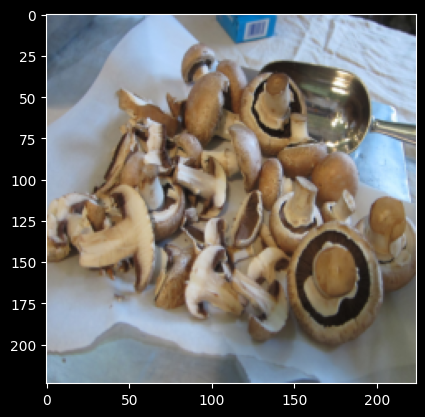

In [ ]:
plt.imshow(images[0].permute(1, 2, 0))


In [ ]:
from torchvision.models import resnet50, ResNet50_Weights

In [ ]:
weights = ResNet50_Weights.DEFAULT
model = resnet50(weights=weights)
model.eval()
pass

In [ ]:
batch = images[0].unsqueeze(0)
mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
batch = (batch - mean) / std
batch.shape

torch.Size([1, 3, 224, 224])

In [ ]:
prediction = model(batch).squeeze(0).softmax(0)
prediction.shape

torch.Size([1000])

In [ ]:
top_3_idx = prediction.argsort(descending=True)[:3]
score_list = prediction[top_3_idx]
score_list

tensor([0.0968, 0.0899, 0.0871], grad_fn=<IndexBackward0>)

In [ ]:
category_names = [weights.meta['categories'][i] for i in top_3_idx.numpy()]
category_names

['bolete', 'hen-of-the-woods', 'mushroom']

In [ ]:
for category, score in list(zip(category_names, score_list)):
    print(f'{category}: {100 * score:.3f}%')


print(category_names[0] == classes[int(labels[0])].lower())

bolete: 9.677%
hen-of-the-woods: 8.986%
mushroom: 8.707%
False
